<a href="https://colab.research.google.com/github/JorgeRf07/Diplomado-Redes-Neuronales-Artificiales/blob/main/Titanic_Fin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Con su dataset deberan realizar lo siguiente:

Preprocesamiento
Limpieza de datos
Creacion de modelo
Clasificacion
Mostrar Matriz de confusion
Mostrar reporte de clasificacion si su dataset no tiene etiquetas deberan cambiarlo por otro.

In [51]:
import pandas as pd
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df =pd.read_csv(URL)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
#importamos las librerias
import numpy as np#para los arreglos
import matplotlib.pyplot as plt#crear graficas
#skelearn sirve para realizar el preprocesamiento
from sklearn.model_selection import train_test_split #division de datos de entrenamiento y prueba
#Estandarizacion de datos
from sklearn.preprocessing import StandardScaler, LabelEncoder
#OneHotEncoder
#Matriz de confusion
from sklearn.metrics import confusion_matrix,classification_report


In [53]:
#cargar las librerias para el modelo de deep leraning
from tensorflow.keras.models import Sequential #Guardamos cada capa del modelo
from tensorflow.keras.layers import Dense#Creamos las neuronas

In [54]:
df.shape

(891, 12)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [56]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
print(df['Embarked'].unique())

['S' 'C' 'Q' nan]


In [58]:
print(df['Embarked'].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [59]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [60]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns
df[columnas_numericas] = df[columnas_numericas].fillna(df[columnas_numericas].mean())

In [61]:
print(df.isnull().sum())
print(df.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
0


In [62]:
X = df.drop('Embarked', axis=1)
y = df['Embarked']
print(X.head())
print(y.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  
0      0         A/5 21171   7.2500   NaN  
1      0          PC 17599  71.2833   C85  
2      0  STON/O2. 3101282   7.9250   NaN  
3      0            113803  53.1000  C123  
4      0            373450   8.0500   NaN  
0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype

In [63]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(y)

[2 0 2 2 2 1 2 2 2 0 2 2 2 2 2 2 1 2 2 0 2 2 1 2 2 2 0 2 1 2 0 0 1 2 0 2 0
 2 2 0 2 2 0 0 1 2 1 1 0 2 2 2 0 2 0 2 2 0 2 2 0 3 2 2 0 0 2 2 2 2 2 2 2 0
 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 1 2
 0 2 2 0 2 1 2 0 2 2 2 0 2 2 0 1 2 0 2 0 2 2 2 2 0 2 2 2 0 0 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 0 2 2 0 2 2 2 0 2 2 2
 2 1 2 1 2 2 2 2 2 0 0 1 2 1 2 2 2 2 0 2 2 2 0 1 0 2 2 2 2 1 0 2 2 0 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 1 2 2 0 1 2 2 2 2 2 2 2 2 2 0 0 2 0
 2 1 2 2 2 1 2 2 2 2 2 2 2 2 0 1 2 2 2 1 2 1 2 2 2 2 0 2 2 2 1 2 0 0 2 2 0
 0 2 2 0 1 1 2 1 2 2 0 0 0 0 0 0 2 2 2 2 2 2 2 0 2 2 1 2 2 0 2 2 2 0 1 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 2 2 2 1 1 2 0 0 2 1 2 0 0 1 0
 0 2 2 0 2 0 2 0 0 2 0 0 2 2 2 2 2 2 1 0 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 1 2 2 2 2 2 2 2 0 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 0 2 2 2 0 0 2 0 2 2 2 1 2 2 2 2 2 2 2 2 1 0 2 2 2 0 2 2 2 2 2 2 2
 2 2 2 0 2 2 0 2 2 2 2 2 

In [64]:
print(encoder.classes_)

['C' 'Q' 'S' nan]


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
print(X_train)
print(X_test)
print(y_train)
print(y_test)

     PassengerId  Survived  Pclass  \
631          632         0       3   
627          628         1       1   
671          672         0       1   
230          231         1       1   
617          618         0       3   
..           ...       ...     ...   
179          180         0       3   
733          734         0       2   
464          465         0       3   
95            96         0       3   
170          171         0       1   

                                                Name     Sex        Age  \
631                      Lundahl, Mr. Johan Svensson    male  51.000000   
627                    Longley, Miss. Gretchen Fiske  female  21.000000   
671                           Davidson, Mr. Thornton    male  31.000000   
230     Harris, Mrs. Henry Birkhardt (Irene Wallach)  female  35.000000   
617  Lobb, Mrs. William Arthur (Cordelia K Stanlick)  female  26.000000   
..                                               ...     ...        ...   
179               

In [67]:
scalar = StandardScaler()

# Select only numeric columns for scaling
numeric_cols_train = X_train.select_dtypes(include=[np.number]).columns
numeric_cols_test = X_test.select_dtypes(include=[np.number]).columns

X_train_numeric = X_train[numeric_cols_train]
X_test_numeric = X_test[numeric_cols_test]

X_train_scaled = scalar.fit_transform(X_train_numeric)
X_test_scaled = scalar.transform(X_test_numeric)

# Optionally, convert back to DataFrame if needed, with original column names
X_train = pd.DataFrame(X_train_scaled, columns=numeric_cols_train, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=numeric_cols_test, index=X_test.index)

print(X_train)
print(X_test)

     PassengerId  Survived    Pclass       Age     SibSp    Parch      Fare
631     0.742882 -0.786245  0.799839  1.622866 -0.508699 -0.48281 -0.483512
627     0.727158  1.271868 -1.613235 -0.669840 -0.508699 -0.48281  0.901348
671     0.900120 -0.786245 -1.613235  0.094395  0.511565 -0.48281  0.394345
230    -0.833426  1.271868 -1.613235  0.400089  0.511565 -0.48281  1.009097
617     0.687849 -0.786245  0.799839 -0.287723  0.511565 -0.48281 -0.306834
..           ...       ...       ...       ...       ...      ...       ...
179    -1.033905 -0.786245  0.799839  0.476513 -0.508699 -0.48281 -0.621290
733     1.143838 -0.786245 -0.406698 -0.516993 -0.508699 -0.48281 -0.367382
464     0.086415 -0.786245  0.799839 -0.005023 -0.508699 -0.48281 -0.464062
95     -1.364104 -0.786245  0.799839 -0.005023 -0.508699 -0.48281 -0.464062
170    -1.069283 -0.786245 -1.613235  2.387102 -0.508699 -0.48281  0.033013

[712 rows x 7 columns]
     PassengerId  Survived    Pclass       Age     SibSp     Par

In [68]:
modelo = Sequential([
    Dense(7, activation="relu",input_shape=(7,)),
    Dense(7, activation="relu"),
    Dense(7, activation="softmax")
])
modelo.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168 (672.00 B)

 Trainable params: 168 (672.00 B)

 Non-trainable params: 0 (0.00 B)

In [69]:
modelo.compile(optimizer = "SGD",loss = "sparse_categorical_crossentropy",metrics=["accuracy"])

In [70]:
historial = modelo.fit(X_train,y_train,epochs = 100, batch_size = 10, validation_split=0.2, verbose=1)


Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6046 - loss: 1.5589 - val_accuracy: 0.7203 - val_loss: 1.2654
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 1.1929 - val_accuracy: 0.7552 - val_loss: 1.0014
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 1.0282 - val_accuracy: 0.7552 - val_loss: 0.8972
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 0.9569 - val_accuracy: 0.7552 - val_loss: 0.8489
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 0.9143 - val_accuracy: 0.7552 - val_loss: 0.8159
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 0.8822 - val_accuracy: 0.7552 - val_loss: 0.7913
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 0.8572 - val_accuracy: 0.7552 - val_loss: 0.7702
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 0.8374 - val_accuracy: 0.7552 - v

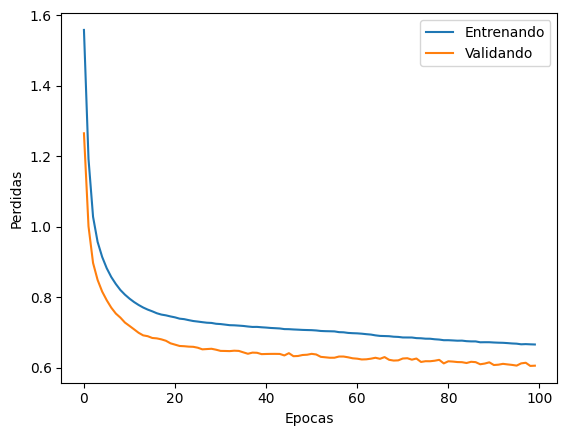

In [71]:
plt.plot(historial.history["loss"],label="Entrenando")
plt.plot(historial.history["val_loss"],label="Validando")
plt.xlabel("Epocas")
plt.ylabel("Perdidas")
plt.legend("Curva de aprendizaje con la perdida")
plt.legend()
plt.show()


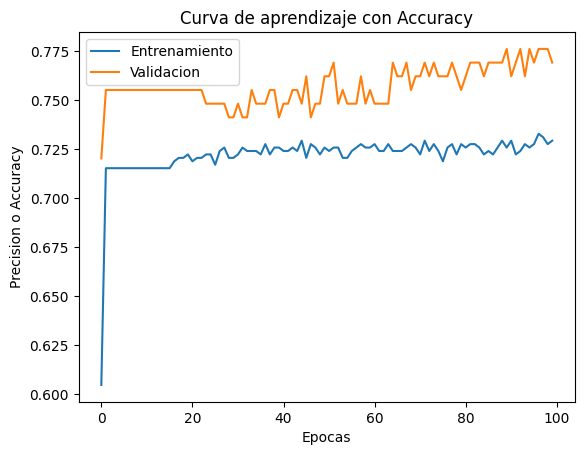

In [72]:
plt.plot(historial.history["accuracy"],label="Entrenamiento")
plt.plot(historial.history["val_accuracy"],label="Validacion")
plt.xlabel("Epocas")
plt.ylabel("Precision o Accuracy")
plt.title("Curva de aprendizaje con Accuracy")
plt.legend()
plt.show()

In [73]:
loss, accuracy = modelo.evaluate(X_test,y_test)
print("Loss",loss)
print("Accuracy",accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7095 - loss: 0.7187 
Loss 0.718676745891571
Accuracy 0.7094972133636475


In [74]:
probabilidades = modelo.predict(X_test)
print(y_test[1])
print(probabilidades[1])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
0
[5.0649697e-01 6.3851536e-03 4.8326546e-01 1.8501295e-03 4.7800294e-04
 1.2206704e-03 3.0361832e-04]


In [75]:
predicciones = np.argmax(probabilidades,axis=1)
print(predicciones)

[2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2
 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0
 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2]


In [76]:
resultados = pd.DataFrame({"Real":y_test,"Prediccion":predicciones})
print(resultados)

     Real  Prediccion
0       2           2
1       0           0
2       2           2
3       2           2
4       2           2
..    ...         ...
174     2           2
175     2           2
176     2           2
177     0           2
178     0           2

[179 rows x 2 columns]


In [77]:
matriz = confusion_matrix(y_test,predicciones)
print(matriz)

[[  3   0  31]
 [  0   0  16]
 [  5   0 124]]


In [78]:
print(classification_report(y_test,predicciones,target_names=[str(c) for c in encoder.classes_],
#target_names=[str(c) for c in encoder.classes_]: Define los nombres que se usarán para cada clase en el reporte.
#Aquí, toma las clases originales de LabelEncoder (encoder.classes_), que incluyen 'C', 'Q', 'S' y nan,
#y las convierte a strings para asegurar que puedan ser usadas como etiquetas.
                            labels=np.arange(len(encoder.classes_))))
#LabelEncoder asignó, incluso si alguna de esas etiquetas no aparece en tu y_test.
#Esto evita errores cuando una clase no tiene muestras en el conjunto de prueba, como vimos con la clase nan.



              precision    recall  f1-score   support

           C       0.38      0.09      0.14        34
           Q       0.00      0.00      0.00        16
           S       0.73      0.96      0.83       129
         nan       0.00      0.00      0.00         0

    accuracy                           0.71       179
   macro avg       0.28      0.26      0.24       179
weighted avg       0.59      0.71      0.62       179



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/me